# 🖼️📜 Image Captioning using CNN-RNN (DenseNet + LSTM)

> Generate meaningful captions from images using a hybrid Deep Learning architecture combining DenseNet201 for image embeddings and LSTM for sequence modeling.

🔍 **What's Inside:**
- 📊 Data preprocessing: cleaning captions + tokenization  
- 🧠 Feature extraction with pretrained CNN  
- 🛠️ Sequence model with custom data generator  
- 🏗️ Captioning architecture inspired by **"Show and Tell"**  
- 🎯 Evaluation with sample predictions

> 📚 Dataset: **Flickr8k**
>  
> 💡 Ideal for understanding the combo of **Vision + Language** in DL!

📌 Tags: `image-captioning`, `cnn`, `rnn`, `lstm`, `densenet`, `keras`, `nlp`, `computer-vision`

In [1]:
## 📦 Imports and Setup

import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Activation, Dropout, Flatten, Dense, Input, Layer
from tensorflow.keras.layers import Embedding, LSTM, add, Concatenate, Reshape, concatenate, Bidirectional
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet201
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap

plt.rcParams['font.size'] = 12
sns.set_style("dark")
warnings.filterwarnings('ignore')

## 🧠 What is Image Captioning?

Image Captioning is the task of generating textual descriptions for images using Deep Learning—specifically, combining **Computer Vision (CNNs)** and **Natural Language Processing (RNNs)**.

- 🧠 CNNs extract meaningful features from the image.
- 🧠 RNNs (LSTMs) generate sequences of words to describe the image.
- 🔁 This typically uses an encoder-decoder structure (image embedding + word generation).

📌 For architecture overview:
<img src="https://miro.medium.com/max/1400/1*6BFOIdSHlk24Z3DFEakvnQ.png">

In [7]:
## 📂 Load Dataset
data = pd.read_csv(r"C:\Users\ABC\Downloads\captions.txt.zip")
data.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


FileNotFoundError: [Errno 2] No such file or directory: '../input/flickr8k/Images/2939007933_8a6ef2d073.jpg'

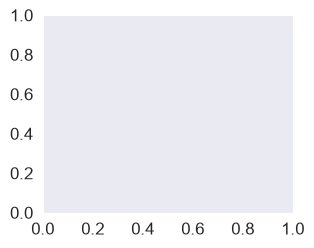

In [8]:
## 🧹 Preprocessing + Visualization

# Helper: Load image and resize
def readImage(path, img_size=224):
    img = load_img(path, color_mode='rgb', target_size=(img_size, img_size))
    img = img_to_array(img) / 255.0
    return img

# Helper: Show 15 random images with captions
def display_images(temp_df):
    temp_df = temp_df.reset_index(drop=True)
    plt.figure(figsize=(20, 20))
    for i in range(15):
        plt.subplot(5, 5, i+1)
        plt.subplots_adjust(hspace=0.7, wspace=0.3)
        image = readImage(f"../input/flickr8k/Images/{temp_df.image[i]}")
        plt.imshow(image)
        plt.title("\n".join(wrap(temp_df.caption[i], 20)))
        plt.axis("off")

display_images(data.sample(15))

## 🧼 Caption Text Cleaning

- Convert to lowercase
- Remove special characters + single characters
- Remove extra spaces
- Add `startseq` and `endseq` to each caption for sequence modeling

In [ ]:
def text_preprocessing(data):
    data['caption'] = data['caption'].apply(lambda x: x.lower())
    data['caption'] = data['caption'].str.replace("[^a-z ]", "", regex=True)
    data['caption'] = data['caption'].str.replace("\s+", " ", regex=True)
    data['caption'] = data['caption'].apply(lambda x: " ".join([word for word in x.split() if len(word) > 1]))
    data['caption'] = "startseq " + data['caption'] + " endseq"
    return data

data = text_preprocessing(data)
captions = data['caption'].tolist()
captions[:10]

## 🧾 Tokenization + Data Split

- Tokenize and encode words to sequences
- Calculate `vocab_size` and `max_length`
- Train/Validation split by unique image filenames

<img src='https://lena-voita.github.io/resources/lectures/word_emb/lookup_table.gif'>

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions)

images = data['image'].unique().tolist()
nimages = len(images)

split_index = round(0.85*nimages)
train_images = images[:split_index]
val_images = images[split_index:]

train = data[data['image'].isin(train_images)]
test = data[data['image'].isin(val_images)]

train.reset_index(inplace=True,drop=True)
test.reset_index(inplace=True,drop=True)

tokenizer.texts_to_sequences([captions[1]])[0]

## 🧠 Image Feature Extraction (DenseNet201)

- Use pretrained DenseNet201 to extract features
- Final output layer is a 1920-d vector (from GlobalAveragePooling)

<img src="https://imgur.com/wWHWbQt.jpg">

In [ ]:
model = DenseNet201()
fe = Model(inputs=model.input, outputs=model.layers[-2].output)

img_size = 224
features = {}
for image in tqdm(data['image'].unique().tolist()):
    img = load_img(os.path.join(image_path,image),target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.
    img = np.expand_dims(img,axis=0)
    feature = fe.predict(img, verbose=0)
    features[image] = feature

## ⚙️ Custom Data Generator

Used to yield batches of image features and corresponding caption sequences for memory-efficient training.

In [ ]:
class CustomDataGenerator(Sequence):
    def __init__(self, df, X_col, y_col, batch_size, directory, tokenizer, 
                 vocab_size, max_length, features, shuffle=True):
        self.df = df.copy()
        self.X_col = X_col
        self.y_col = y_col
        self.directory = directory
        self.batch_size = batch_size
        self.tokenizer = tokenizer
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.features = features
        self.shuffle = shuffle
        self.n = len(self.df)

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __len__(self):
        return self.n // self.batch_size

    def __getitem__(self, index):
        batch = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size, :]
        X1, X2, y = self.__get_data(batch)        
        return (X1, X2), y

    def __get_data(self, batch):
        X1, X2, y = [], [], []
        images = batch[self.X_col].tolist()

        for image in images:
            feature = self.features[image][0]
            captions = batch.loc[batch[self.X_col] == image, self.y_col].tolist()
            for caption in captions:
                seq = self.tokenizer.texts_to_sequences([caption])[0]
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=self.max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=self.vocab_size)[0]
                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

        return np.array(X1), np.array(X2), np.array(y)

## 🏗️ Captioning Model (DenseNet201 + LSTM)

Architecture inspired by 📄 "Show and Tell: A Neural Image Caption Generator"  
- Merge image features + sentence embeddings
- Use LSTM to predict next word

In [ ]:
input1 = Input(shape=(1920,))
input2 = Input(shape=(max_length,))

img_features = Dense(256, activation='relu')(input1)
img_features_reshaped = Reshape((1, 256))(img_features)

sentence_features = Embedding(vocab_size, 256, mask_zero=False)(input2)
merged = concatenate([img_features_reshaped, sentence_features], axis=1)
sentence_features = LSTM(256)(merged)

x = Dropout(0.5)(sentence_features)
x = add([x, img_features])
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(vocab_size, activation='softmax')(x)

caption_model = Model(inputs=[input1, input2], outputs=output)
caption_model.compile(loss='categorical_crossentropy', optimizer='adam')

## 🚂 Training the Model

In [ ]:
train_generator = CustomDataGenerator(train, 'image', 'caption', 64, image_path, tokenizer, vocab_size, max_length, features)
validation_generator = CustomDataGenerator(test, 'image', 'caption', 64, image_path, tokenizer, vocab_size, max_length, features)

callbacks = [
    ModelCheckpoint("model.h5", monitor="val_loss", save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, min_lr=1e-8)
]

history = caption_model.fit(train_generator, validation_data=validation_generator, epochs=50, callbacks=callbacks)

## 📉 Training Curves

In [ ]:
plt.figure(figsize=(20, 8))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Model Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 🧪 Inference + Caption Generation

Generate captions by sequentially predicting the next word.

In [ ]:
def idx_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def predict_caption(model, image, tokenizer, max_length, features):
    feature = features[image]
    in_text = "startseq"
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        y_pred = model.predict([feature, sequence], verbose=0)
        y_pred = np.argmax(y_pred)
        word = idx_to_word(y_pred, tokenizer)
        if word is None or word == 'endseq':
            break
        in_text += " " + word
    return in_text

## 🖼️ Captions: Sample Results

In [ ]:
samples = test.sample(15).reset_index(drop=True)
for i, row in samples.iterrows():
    img = load_img(os.path.join(image_path, row['image']), target_size=(224, 224))
    img = img_to_array(img) / 255.0
    caption = predict_caption(caption_model, row['image'], tokenizer, max_length, features)
    samples.loc[i, 'caption'] = caption

display_images(samples)

In [ ]:
import pickle

# Save the captioning model
caption_model.save("caption_model.h5")

# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save feature extractor model (DenseNet201)
fe.save("feature_extractor.h5")

# Save max_length and vocab_size
with open("config.pkl", "wb") as f:
    pickle.dump({"max_length": max_length, "vocab_size": vocab_size}, f)

## ✅ Conclusion + Next Steps

This model gives a solid baseline for image captioning using CNN + RNNs. But there’s room to improve:

- 🧠 Try **Attention-based Models** (like Show, Attend and Tell)
- 🔄 Use **BLEU / METEOR** for objective scoring
- 📈 Train on larger datasets like **Flickr30k**, **MSCOCO**

This is a great intro to vision-language modeling. Let’s build on this 🚀